# Support Vector Machines

## Autores

| Nome | nUSP |
| :--- | :--- |
| Débora da Silva Morais     | 15615790 |
| Guilherme de Abreu Barreto | 12543033 |

## Introdução

Neste exercício damos continuidade a exploração de técnicas de classificação para o problema formulado no artigo de Zanfei et al., [Novel approach for burst detection in water distribution systems based on graph neural networks](https://www.sciencedirect.com/science/article/abs/pii/S2210670722004073). Agora utilizando o PCA para a redução de dimensionalidade e o SVM (Support Vector Machines) para a classificação das amostras em 5 folds de classificação cruzada.

## Carregamento de dependências

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from plotly.graph_objects import Figure, Scatter3d, Cone
from sklearn.svm import SVC
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV, StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    roc_curve,
    r2_score,
    auc
)

## Configuração das constantes

Aqui estabelecemos os conjuntos de dados que serão trabalhados, as variáveis independentes (_features_) e a variável dependente (_target_)

In [2]:
SEED = 42
np.random.seed(SEED)

# Dados referentes a tarefa de classificação
WDTS_DATASETS_FOLDER = '../generated-datasets-for-burst-detection-in-water-distribution-systems'
WDTS_DATASETS = [
    f'{WDTS_DATASETS_FOLDER}/WDts{i}/WDts{i}_dataset.csv' for i in range(1, 5)
]

target = 'burst'
features = [
    f'flow_meter{i}' for i in range(1, 5)
] + [
    f'{i}_press' for i in [3, 12, 36, 50, 60, 84, 93, 112, 138, 139]
]

## Funções

A seguir são estabelecidas as funções aquelas que descrevem procedimentos os quais serão repetidos para cada conjunto de dados

### Carregamento dos dados

A seguinte função a seguir carrega na memória primária um objeto do tipo _dataframe_ com todos os dados de um dado conjunto de dados, substituindo valores faltantes (se estes houverem) pelo valor médio para cada atributo.

In [3]:
def load_wdts_data(
    csv_path: str, features: list[str], target: str
) -> tuple[pd.DataFrame, pd.Series]:
    df = pd.read_csv(
        csv_path,
        dtype={target: bool},
        index_col=False,
        sep=';',
    )
    df = df[df[target].notna()]
    return df[features].fillna(df[features].mean()), df[target]

### Análise de componentes principais

#### Mapa de calor

Demonstra o alinhamento de cada _feature_ para com cada eixo ortogonal (1 para perfeitamente alinhado no sentido positivo, 0 para perfeitamente ortogonal, -1 para perfeitamente alinhado no sentido negativo) gerado pelo PCA, assim como o percentual de variância capturado por cada um destes eixos.

In [4]:
def pca_heatmap(pca, feature_names) -> None:
    pca_columns = [f"PC{i+1}" for i in range(pca.n_components_)]
    
    # Create loadings heatmap
    plt.figure(figsize=(10, 6))
    sns.heatmap(
        pd.DataFrame(
            pca.components_.T,  # Transpose to align columns with PCs
            columns=pca_columns,
            index=feature_names
        ),
        annot = True,
        cmap = 'coolwarm',
        center = 0
    )
    plt.title("Loadings (Orientação das colunas originais aos componentes principais)")
    plt.tight_layout()
    plt.show()
    
    # Display variance
    display(
        pd.DataFrame({
            'Componente Principal': pca_columns,
            'Variância explicada (%)': pca.explained_variance_ratio_ * 100,
            'Variância cumulativa (%)': np.cumsum(pca.explained_variance_ratio_) * 100
        })
            .style.hide(axis='index')
            .format({
            'Variância explicada (%)': '{:.2f}',
            'Variância cumulativa (%)': '{:.2f}'
        })
    )

#### Gráfico de Scree

Gráfico de linha que representa a relação entre o número de componentes e o total normalizado (de 0 a 1) da variância explicada. Serve para, na inspeção visual, aplicar a técnica do cotovelo para escolher o número de componentes a serem retidos de tal forma a não exacerbar o ajuste do modelo (_overfitting_).

In [5]:
def scree_plot(pca) -> None:
    plt.plot(
        range(1, len(pca.explained_variance_ratio_) + 1), 
        pca.explained_variance_ratio_, 'bo-'
    )
    plt.xlabel('Componentes principais')
    plt.ylabel('Variância explicada')
    plt.title('Gráfico de Scree')
    plt.show()

#### Gráfico de dispersão

Representa espacialmente a disposição das amostras com relação aos três primeiros componentes principais. O aspecto iterativo do gráfico permite a filtragem das classes na exibição.

In [6]:
def pca_scatter(
    pca_scores,
    loadings,
    y,
    features,
    target
) -> None:
    # Get the first 3 principal components
    pc1, pc2, pc3 = pca_scores[:, 0], pca_scores[:, 1],  pca_scores[:, 2]
    
    # Add data points for each class
    fig = Figure()
    fig.add_trace(
        Scatter3d(
            x=pc1[y == False],
            y=pc2[y == False],
            z=pc3[y == False],
            mode='markers',
            marker={
                'size': 4,
                'color': 'blue',
                'opacity': 0.7,
            },
            name=f'{target} == False',  # Name for legend
            showlegend=True,
            legendgroup="False",  # Group for legend interaction
            visible=True  # Start as visible
        )
    )
    
    fig.add_trace(
        Scatter3d(
            x=pc1[y == True],
            y=pc2[y == True],
            z=pc3[y == True],
            mode='markers',
            marker={
                'size': 4,
                'color': 'red',
                'opacity': 0.7,
            },
            name=f'{target} == True',  # Name for legend
            showlegend=True,
            legendgroup="True",  # Group for legend interaction
            visible=True  # Start as visible
        )
    )
    
    # Add loading arrows - group them separately so they don't get toggled
    arrow_scale = 2.5
    for i, feature in enumerate(features):
        # Add arrow line
        fig.add_trace(
            Scatter3d(
                x=[0, loadings[i, 0] * arrow_scale],
                y=[0, loadings[i, 1] * arrow_scale],
                z=[0, loadings[i, 2] * arrow_scale],
                mode='lines',
                line={'color':'black', 'width': 3},
                showlegend=False,
                hoverinfo='none',
                legendgroup="loadings",  # Group all loadings together
                visible=True
            )
        )
    
        # Arrowhead
        fig.add_trace(Scatter3d(
            x=[loadings[i, 0] * arrow_scale],
            y=[loadings[i, 1] * arrow_scale],
            z=[loadings[i, 2] * arrow_scale],
            mode='markers',
            marker={'size': 5, 'color': 'darkred', 'symbol': 'diamond'},
            showlegend=False,
            hoverinfo='none',
            legendgroup="loadings",
            visible=True
        ))
    
        # Feature label
        fig.add_trace(Scatter3d(
            x=[loadings[i, 0] * arrow_scale * 1.15],
            y=[loadings[i, 1] * arrow_scale * 1.15],
            z=[loadings[i, 2] * arrow_scale * 1.15],
            mode='text',
            text=[feature],
            textposition='middle center',
            showlegend=False,
            hoverinfo='none',
            legendgroup="loadings",
            visible=True
        ))
    
    fig.update_layout(
        title='Gráfico de dispersão 3D com o carregamento dos parâmetros',
        scene={
            'xaxis_title': 'PC1',
            'yaxis_title': 'PC2', 
            'zaxis_title': 'PC3',
            'camera': {'eye': {'x': 1.5, 'y': 1.5, 'z': 1.5}}
        },
        width=800,
        height=600,
        showlegend=True,
        legend=dict(
            x=0.8,
            y=0.9,
            bgcolor='rgba(255,255,255,0.8)',
            bordercolor='black',
            borderwidth=1,
            # Configure legend interaction behavior
            groupclick="toggleitem"  # This allows individual toggling
        )
    )
    
    fig.show()

#### Cálculo do PCA

Calcula e devolve os valores calculados para o PCA, exibindo os resultados ao fazê-lo.

In [7]:
def pca_analysis(
    X: pd.DataFrame,
    y: pd.Series,
    features: list[str],
    target: str
) -> pd.DataFrame:
    scaled_features = StandardScaler().fit_transform(X)
    pca = PCA(n_components=scaled_features.shape[1])
    pca_scores = pca.fit_transform(scaled_features)

    feature_names = X.columns.tolist()
    pca_heatmap(pca, features)
    scree_plot(pca)
    pca_scatter(pca_scores, pca.components_[:3].T, y, features, target)
    return pca_scores

### Aplicação do SVM com validação cruzada

Aplica a técnica SVM com uma variedade de combinações possíveis de hiperparâmetros para 4 diferentes fórmulas de se calcular a relação entre duas observação em um espaço de dimensão mais elevada, retornando a combinação que obteve o melhor desempenho em termos da [pontuação F1](https://en.wikipedia.org/wiki/F-score). Os valores escolhidos para os hiperparâmetros encontram-se em uma progressão de escala logarítmica.

In [14]:
def svm_halving_search(X, y, folds=3, scoring='f1'):
    pipeline = Pipeline([('svm', SVC(class_weight='balanced', probability=True))])
    
    # Structured parameter grid (same as your original but optimized)
    param_grid = [
        # RBF Kernel - most likely to be best
        {
            'svm__kernel': ['rbf'],
            'svm__C': [0.1, 1, 10, 100],
            'svm__gamma': ['scale', 0.001, 0.01, 0.1, 1]
        },
        # Linear Kernel - simple and fast
        {
            'svm__kernel': ['linear'],
            'svm__C': [0.01, 0.1, 1, 10, 100]
        },
        # Polynomial Kernel - only if needed
        {
            'svm__kernel': ['poly'],
            'svm__C': [0.1, 1, 10],
            'svm__gamma': ['scale', 0.01, 0.1],
            'svm__degree': [2, 3],
            'svm__coef0': [0, 1]
        }
    ]

    cv_strategy = StratifiedKFold(n_splits=folds, shuffle=True, random_state=SEED)
    
    halving_search = HalvingGridSearchCV(
        pipeline,
        param_grid,
        cv=cv_strategy,
        scoring=scoring,
        n_jobs=-1,
        verbose=2,
        # Halving parameters - these control the smart elimination
        factor=3,           # Keep top 1/3 of candidates each iteration
        min_resources='exhaust',
        aggressive_elimination=False, # Be less aggressive for better results
        return_train_score=True
    )
    
    return halving_search.fit(X, y)

### Avaliação dos resultados

Exibe os resuldados da validação cruzada na forma dos gráficos de confusão e Curva ROC, além de sumarizar métricas de desempenho e os hiperparâmetros utilizados para produzir tais resultados

In [27]:
def evaluate_results(
    gs: HalvingGridSearchCV,
    X: np.ndarray,
    y: np.ndarray,
    dataset_name: str = "treino"
) -> None:    
    # Get the best estimator (already trained on full data)
    best_estimator = gs.best_estimator_
    
    # Use the BEST model to make predictions on the SAME data
    # This is much faster than running cross-validation again
    y_pred = best_estimator.predict(X)
    
    # Get probability predictions (if available)
    try:
        y_pred_proba = best_estimator.predict_proba(X)[:, 1]
        proba_available = True
    except (AttributeError, KeyError) as e:
        print(f"⚠️  Probabilities not available: {e}")
        y_pred_proba = None
        proba_available = False

    # Print confusion matrix
    cm = confusion_matrix(y, y_pred)
    cm_percentage = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    plt.figure(figsize=(8,6))
    labels = ["Falso", "Verdadeiro"]
    sns.heatmap(
        cm_percentage,
        annot=True,
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
        fmt='.2f'
    )
    plt.xlabel('Previsão')
    plt.ylabel('Realidade')
    plt.title(f"Matriz de confusão - Treino ({dataset_name})")
    plt.show()

    # Print ROC Curve if probabilities available
    if proba_available and y_pred_proba is not None:
        fpr, tpr, thresholds = roc_curve(y, y_pred_proba)
        auc = roc_auc_score(y, y_pred_proba)

        plt.figure(figsize=(10,8))
        plt.plot(
            fpr,
            tpr,
            color='darkorange',
            lw=2,
            label=f'Área sob a curva = {auc:.4f}'
        )
        plt.plot(
            [0, 1],
            [0, 1],
            color='navy',
            lw=2,
            linestyle='--',
            label='Classificador aleatório'
        )
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('Taxa de falsos positivos')
        plt.ylabel('Taxa de verdadeiros positivos')
        plt.title(f'Curva ROC - Treino ({dataset_name})')
        plt.legend(loc='lower right')
        plt.grid(True, alpha=0.3)
        plt.show()
    else:
        print("⚠️  ROC curve skipped - probability estimates not available")
        auc = np.nan

    # Generic best parameters summary
    print("\n" + "=" * 60)
    print("MELHORES HIPERPARÂMETROS")
    print("=" * 60)
    
    for param_name, param_value in gs.best_params_.items():
        clean_param_name = param_name.split('__')[-1] if '__' in param_name else param_name
        
        if isinstance(param_value, (list, tuple, np.ndarray)):
            formatted_value = ' × '.join(map(str, param_value))
        elif isinstance(param_value, float):
            formatted_value = f"{param_value:.6f}"
        else:
            formatted_value = str(param_value)
        
        print(f"{clean_param_name:.<25} {formatted_value}")
    
    # Performance metrics (using training performance)
    print(f"\n{'Desempenho no Treino':-^40}")
    print(f"{'F1-Score (CV)':.<25} {gs.best_score_:.4f}")  # From grid search CV
    if not np.isnan(auc):
        print(f"{'Área sob a curva ROC':.<25} {auc:.4f}")
    print(f"{'Acurácia (Treino)':.<25} {accuracy_score(y, y_pred):.4f}")

## Aplicação

### Conjunto WDts1

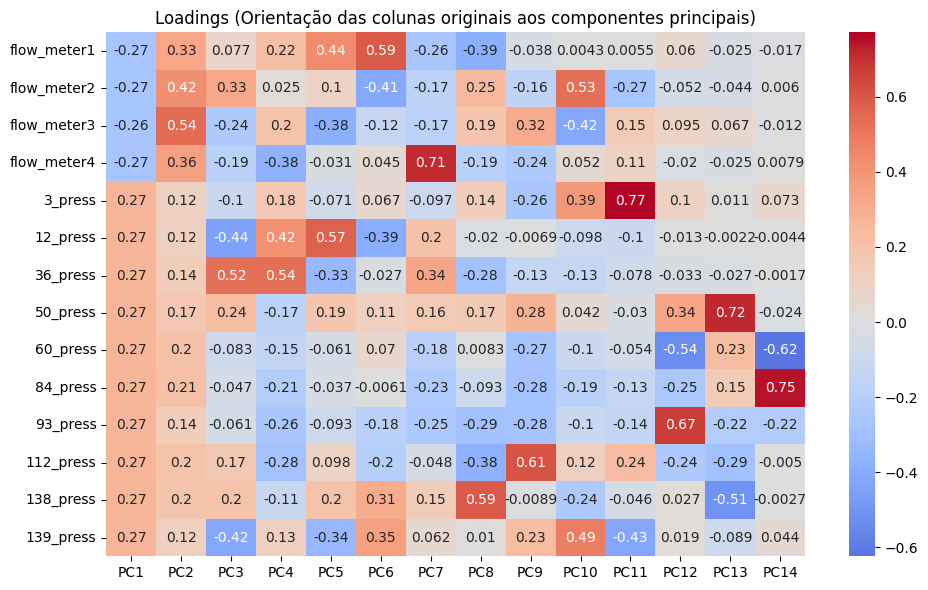

Componente Principal,Variância explicada (%),Variância cumulativa (%)
PC1,98.95,98.95
PC2,0.63,99.58
PC3,0.18,99.76
PC4,0.11,99.86
PC5,0.04,99.90
PC6,0.04,99.94
PC7,0.02,99.96
PC8,0.01,99.98
PC9,0.01,99.98
PC10,0.01,99.99


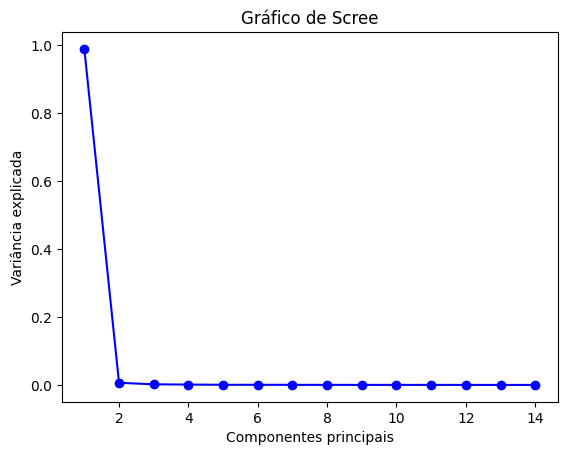

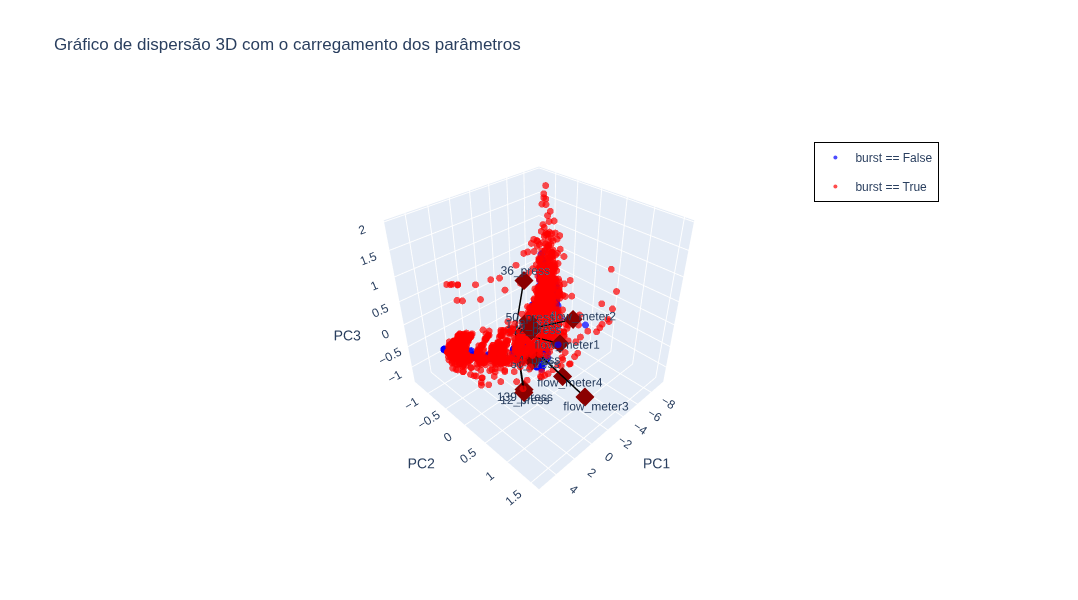

In [10]:
X, y = load_wdts_data(WDTS_DATASETS[0], features, target)
pca_scores = pca_analysis(X, y, features, target)

In [16]:
new_X = pca_scores[:, :2]
gs = svm_halving_search(new_X, y)

n_iterations: 4
n_required_iterations: 4
n_possible_iterations: 4
min_resources_: 1297
max_resources_: 35040
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 61
n_resources: 1297
Fitting 3 folds for each of 61 candidates, totalling 183 fits
----------
iter: 1
n_candidates: 21
n_resources: 3891
Fitting 3 folds for each of 21 candidates, totalling 63 fits
----------
iter: 2
n_candidates: 7
n_resources: 11673
Fitting 3 folds for each of 7 candidates, totalling 21 fits
----------
iter: 3
n_candidates: 3
n_resources: 35019
Fitting 3 folds for each of 3 candidates, totalling 9 fits
[CV] END ......svm__C=0.1, svm__gamma=scale, svm__kernel=rbf; total time=   0.3s
[CV] END ......svm__C=0.1, svm__gamma=0.001, svm__kernel=rbf; total time=   0.3s
[CV] END ........svm__C=0.1, svm__gamma=0.1, svm__kernel=rbf; total time=   0.3s
[CV] END ..........svm__C=0.1, svm__gamma=1, svm__kernel=rbf; total time=   0.3s
[CV] END ........svm__C=1, svm__gamma=scale, svm__kernel=rbf; total t

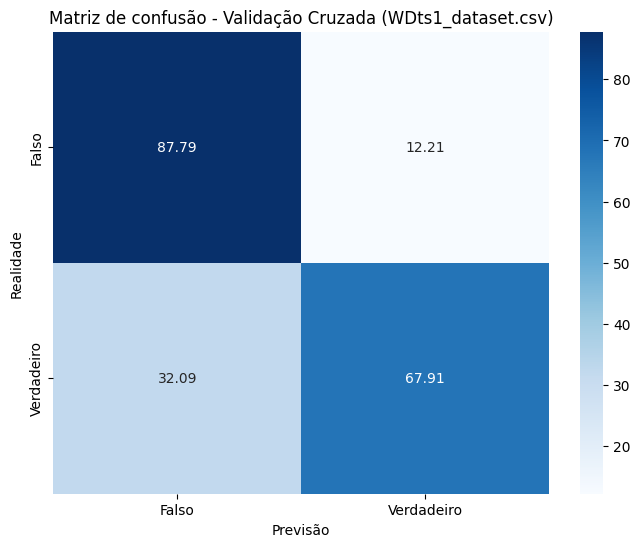

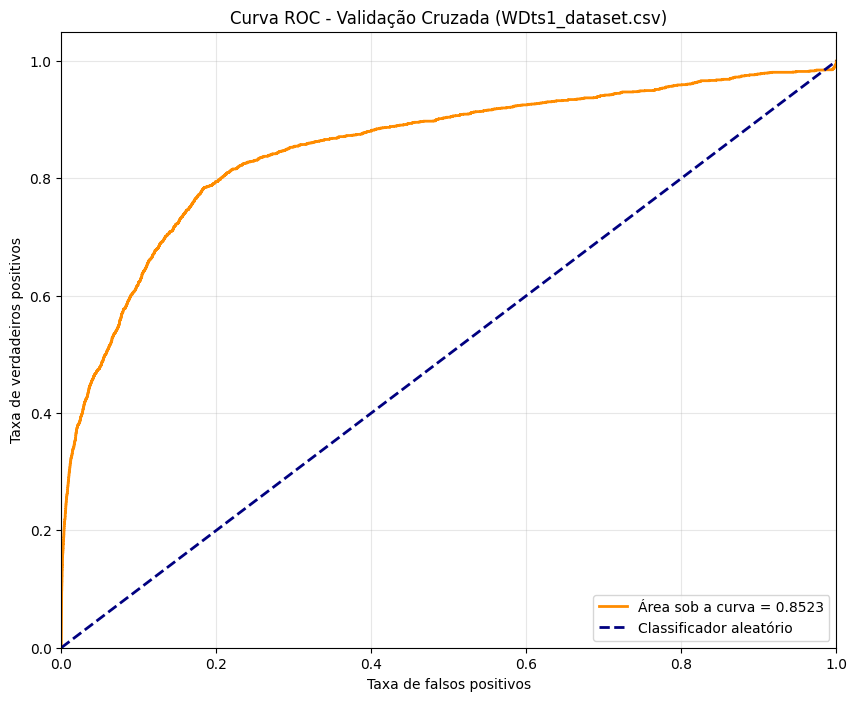


MELHORES HIPERPARÂMETROS
C........................ 100
gamma.................... 1
kernel................... rbf

----Desempenho na Validação Cruzada-----
F1-Score................. 0.3758
Área sob a curva ROC..... 0.8523
Acurácia................. 0.8660

----------Métricas Detalhadas-----------


NameError: name 'precision_score' is not defined

In [19]:
evaluate_results(
    gs,
    new_X,
    y,
    WDTS_DATASETS[0].rsplit('/', 1)[-1]
)

### Conjunto WDts2

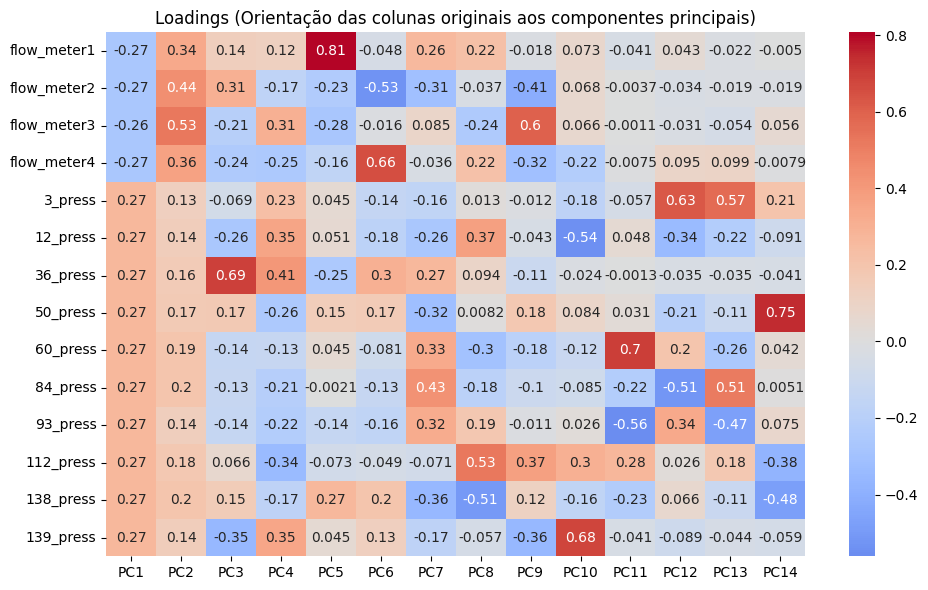

Componente Principal,Variância explicada (%),Variância cumulativa (%)
PC1,98.86,98.86
PC2,0.76,99.62
PC3,0.17,99.79
PC4,0.09,99.88
PC5,0.04,99.92
PC6,0.03,99.95
PC7,0.02,99.96
PC8,0.01,99.98
PC9,0.01,99.99
PC10,0.01,99.99


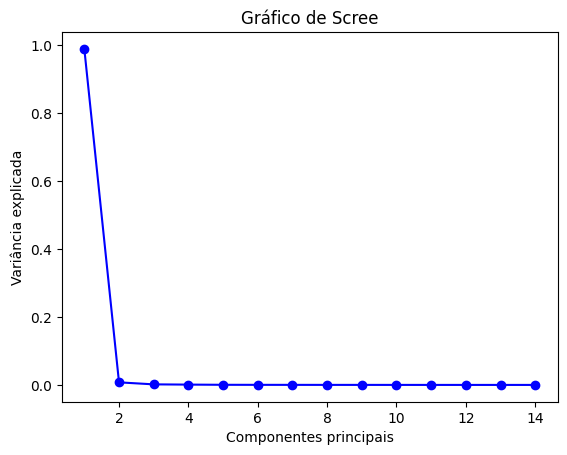

In [24]:
X, y = load_wdts_data(WDTS_DATASETS[1], features, target)
pca_scores = pca_analysis(X, y, features, target)

In [25]:
new_X = pca_scores[:, :2]
gs = svm_halving_search(new_X, y)

n_iterations: 4
n_required_iterations: 4
n_possible_iterations: 4
min_resources_: 1297
max_resources_: 35040
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 61
n_resources: 1297
Fitting 3 folds for each of 61 candidates, totalling 183 fits
----------
iter: 1
n_candidates: 21
n_resources: 3891
Fitting 3 folds for each of 21 candidates, totalling 63 fits
----------
iter: 2
n_candidates: 7
n_resources: 11673
Fitting 3 folds for each of 7 candidates, totalling 21 fits
----------
iter: 3
n_candidates: 3
n_resources: 35019
Fitting 3 folds for each of 3 candidates, totalling 9 fits
[CV] END ......svm__C=0.1, svm__gamma=scale, svm__kernel=rbf; total time=   0.3s
[CV] END .......svm__C=0.1, svm__gamma=0.01, svm__kernel=rbf; total time=   0.3s
[CV] END ........svm__C=0.1, svm__gamma=0.1, svm__kernel=rbf; total time=   0.4s
[CV] END ..........svm__C=0.1, svm__gamma=1, svm__kernel=rbf; total time=   0.3s
[CV] END ........svm__C=1, svm__gamma=0.001, svm__kernel=rbf; total t

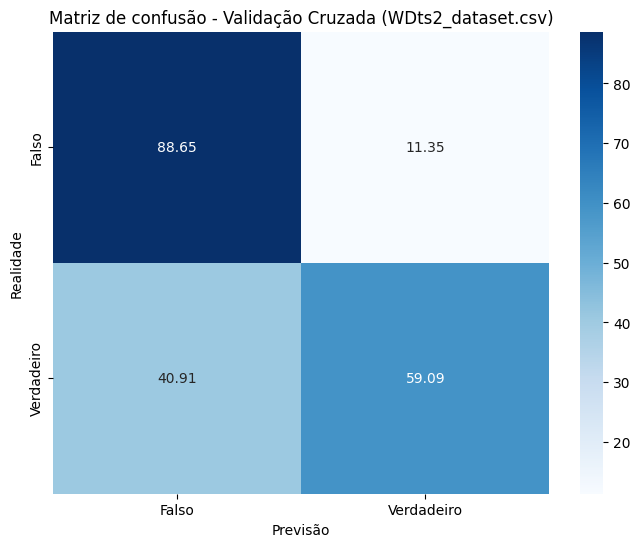

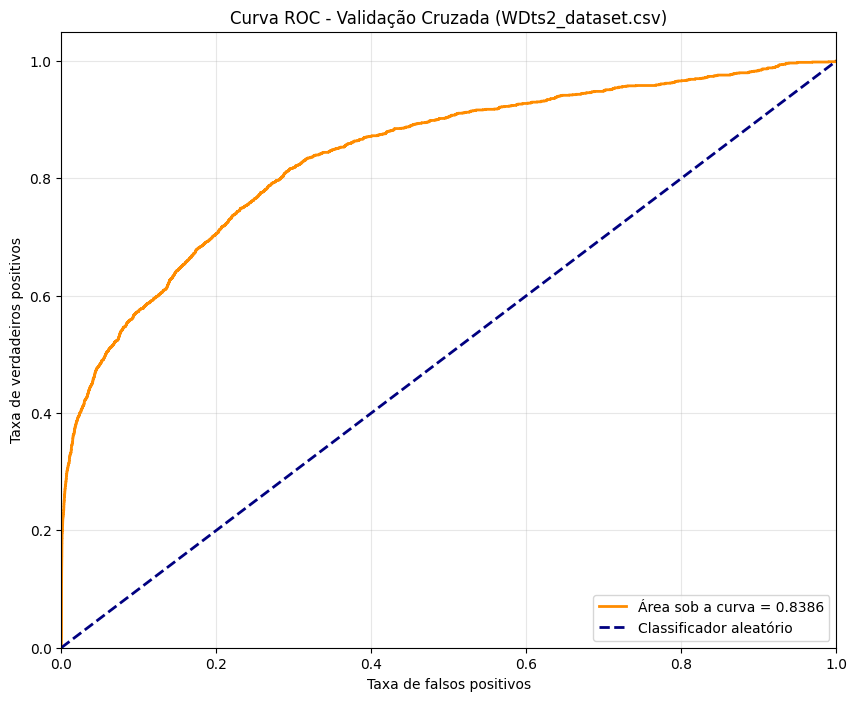


MELHORES HIPERPARÂMETROS
C........................ 100
gamma.................... 1
kernel................... rbf

----Desempenho na Validação Cruzada-----
F1-Score................. 0.3221
Área sob a curva ROC..... 0.8386
Acurácia................. 0.8713

----------Métricas Detalhadas-----------


NameError: name 'precision_score' is not defined

In [26]:
evaluate_results(
    gs,
    new_X,
    y,
    WDTS_DATASETS[1].rsplit('/', 1)[-1]
)

### Conjunto WDts3

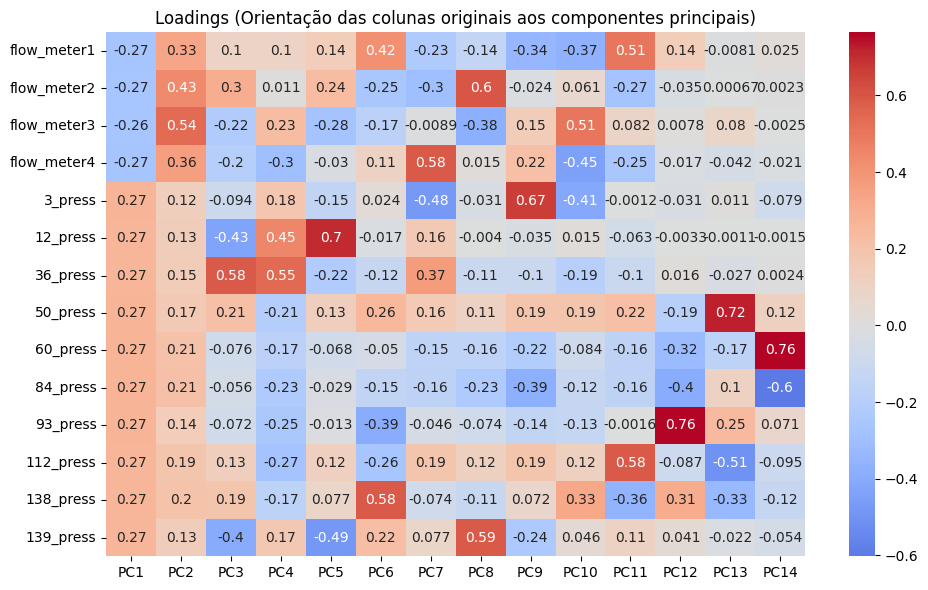

Componente Principal,Variância explicada (%),Variância cumulativa (%)
PC1,98.70,98.70
PC2,0.73,99.44
PC3,0.27,99.70
PC4,0.15,99.85
PC5,0.06,99.91
PC6,0.04,99.94
PC7,0.02,99.96
PC8,0.01,99.98
PC9,0.01,99.98
PC10,0.01,99.99


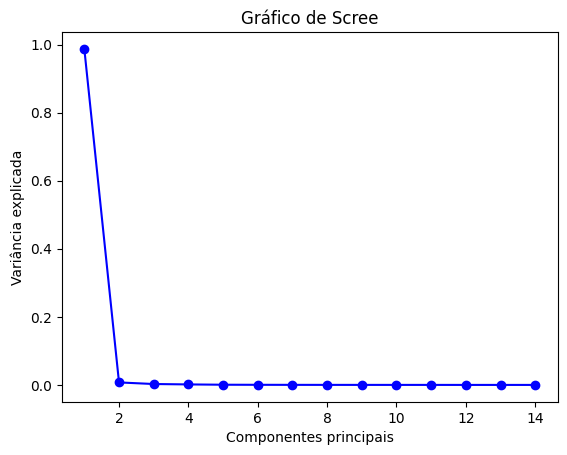

In [28]:
X, y = load_wdts_data(WDTS_DATASETS[2], features, target)
pca_scores = pca_analysis(X, y, features, target)

In [29]:
new_X = pca_scores[:, :2]
gs = svm_halving_search(new_X, y)

n_iterations: 4
n_required_iterations: 4
n_possible_iterations: 4
min_resources_: 1297
max_resources_: 35040
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 61
n_resources: 1297
Fitting 3 folds for each of 61 candidates, totalling 183 fits
----------
iter: 1
n_candidates: 21
n_resources: 3891
Fitting 3 folds for each of 21 candidates, totalling 63 fits
----------
iter: 2
n_candidates: 7
n_resources: 11673
Fitting 3 folds for each of 7 candidates, totalling 21 fits
----------
iter: 3
n_candidates: 3
n_resources: 35019
Fitting 3 folds for each of 3 candidates, totalling 9 fits
[CV] END ......svm__C=0.1, svm__gamma=scale, svm__kernel=rbf; total time=   0.4s
[CV] END .......svm__C=0.1, svm__gamma=0.01, svm__kernel=rbf; total time=   0.3s
[CV] END ........svm__C=0.1, svm__gamma=0.1, svm__kernel=rbf; total time=   1.8s
[CV] END ..........svm__C=0.1, svm__gamma=1, svm__kernel=rbf; total time=   1.0s
[CV] END ........svm__C=1, svm__gamma=0.001, svm__kernel=rbf; total t

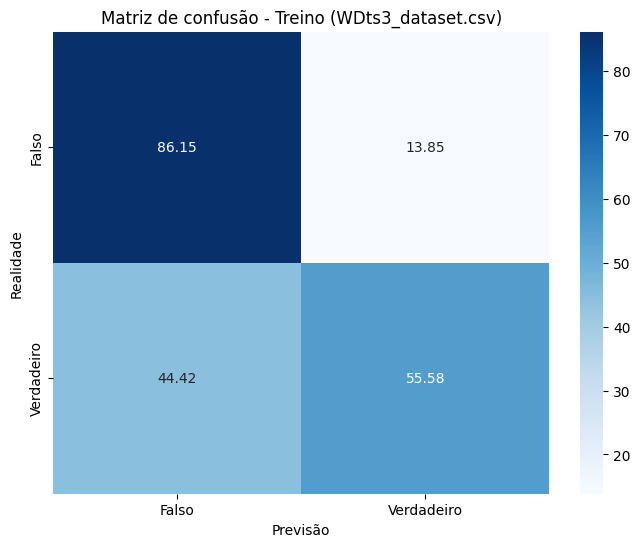

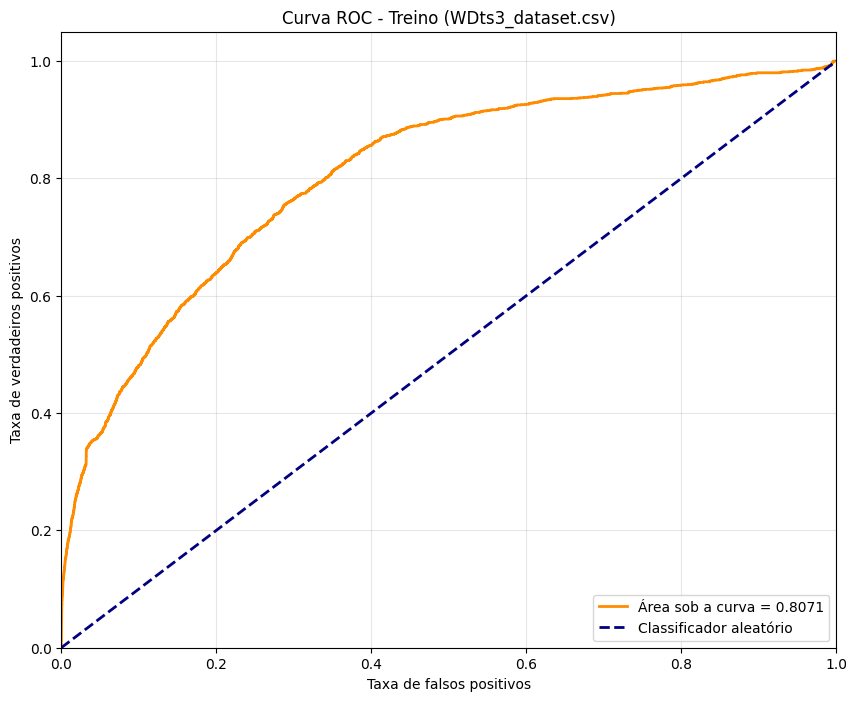


MELHORES HIPERPARÂMETROS
C........................ 100
gamma.................... 1
kernel................... rbf

----------Desempenho no Treino----------
F1-Score (CV)............ 0.2520
Área sob a curva ROC..... 0.8071
Acurácia (Treino)........ 0.8444


In [30]:
evaluate_results(
    gs,
    new_X,
    y,
    WDTS_DATASETS[2].rsplit('/', 1)[-1]
)

### Conjunto WDts4

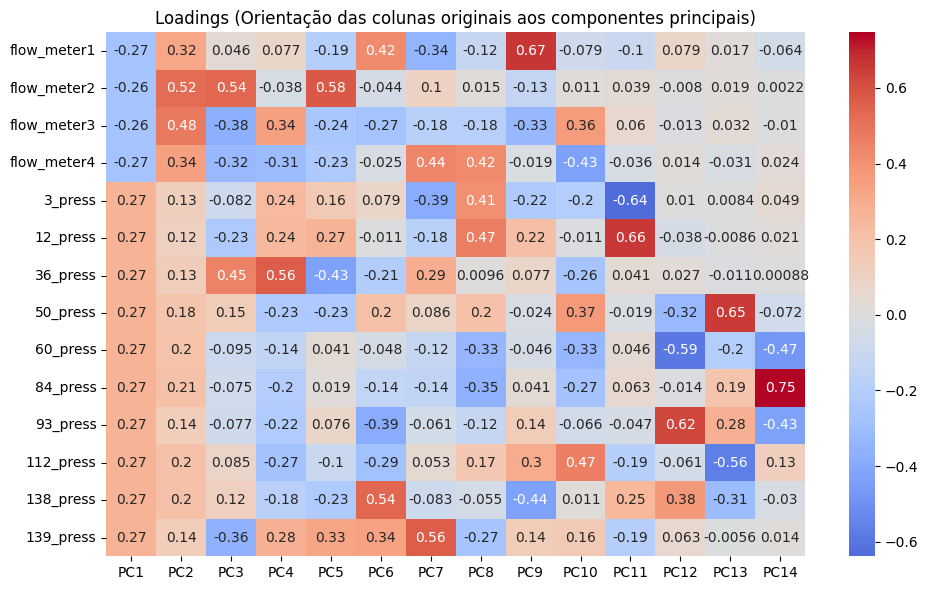

Componente Principal,Variância explicada (%),Variância cumulativa (%)
PC1,98.55,98.55
PC2,0.86,99.41
PC3,0.28,99.69
PC4,0.12,99.81
PC5,0.10,99.92
PC6,0.03,99.95
PC7,0.02,99.97
PC8,0.01,99.98
PC9,0.01,99.98
PC10,0.01,99.99


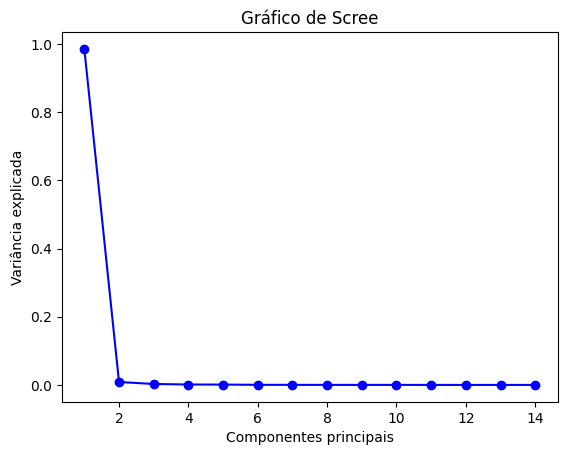

In [31]:
X, y = load_wdts_data(WDTS_DATASETS[3], features, target)
pca_scores = pca_analysis(X, y, features, target)

In [32]:
new_X = pca_scores[:, :2]
gs = svm_halving_search(new_X, y)

n_iterations: 4
n_required_iterations: 4
n_possible_iterations: 4
min_resources_: 1297
max_resources_: 35040
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 61
n_resources: 1297
Fitting 3 folds for each of 61 candidates, totalling 183 fits
----------
iter: 1
n_candidates: 21
n_resources: 3891
Fitting 3 folds for each of 21 candidates, totalling 63 fits
----------
iter: 2
n_candidates: 7
n_resources: 11673
Fitting 3 folds for each of 7 candidates, totalling 21 fits
----------
iter: 3
n_candidates: 3
n_resources: 35019
Fitting 3 folds for each of 3 candidates, totalling 9 fits
[CV] END ......svm__C=0.1, svm__gamma=scale, svm__kernel=rbf; total time=   0.4s
[CV] END .......svm__C=0.1, svm__gamma=0.01, svm__kernel=rbf; total time=   0.4s
[CV] END ........svm__C=0.1, svm__gamma=0.1, svm__kernel=rbf; total time=   0.4s
[CV] END ........svm__C=1, svm__gamma=scale, svm__kernel=rbf; total time=   0.3s
[CV] END ........svm__C=1, svm__gamma=0.001, svm__kernel=rbf; total t

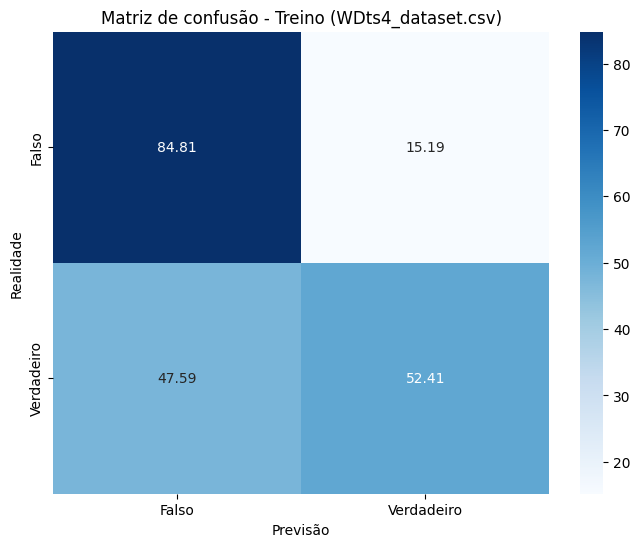

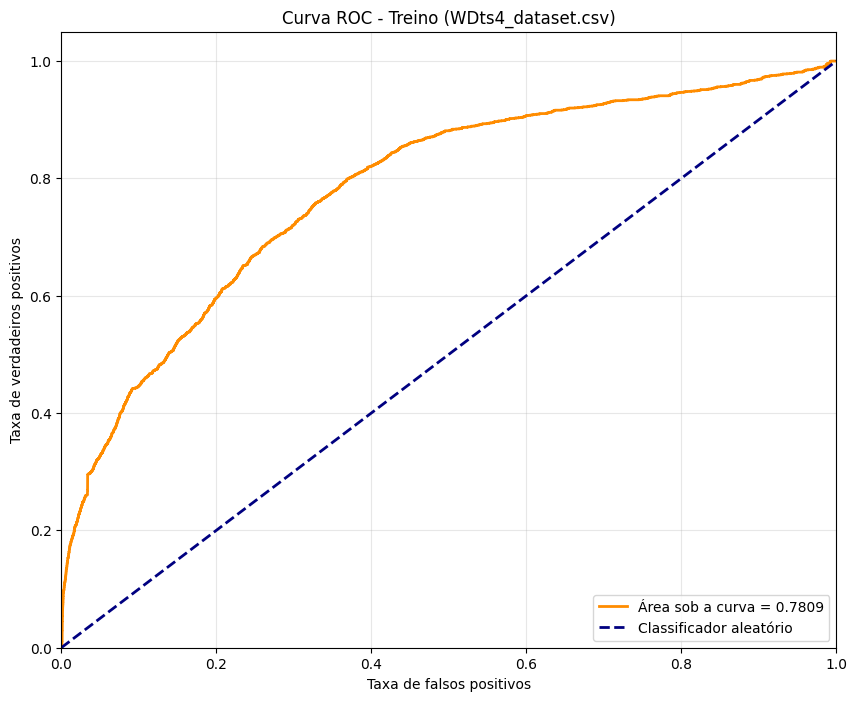


MELHORES HIPERPARÂMETROS
C........................ 100
gamma.................... 1
kernel................... rbf

----------Desempenho no Treino----------
F1-Score (CV)............ 0.2244
Área sob a curva ROC..... 0.7809
Acurácia (Treino)........ 0.8305


In [34]:
evaluate_results(
    gs,
    new_X,
    y,
    WDTS_DATASETS[3].rsplit('/', 1)[-1]
)

## 